# Proyecto 8: Taxis
* Autor: Carlos Francisco Iñiguez Llamas
* Fecha: 2026-03-26

## Paso 4. Análisis exploratorio de datos
### 4.0 Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
from scipy import stats
import seaborn as sns
import numpy as np
import datetime

import modules.decpandas as dp
import modules.pruebas_de_hipotesis as mph

ModuleNotFoundError: No module named 'decpandas'

### 4.1 Importar datos

In [ ]:
# Carga los archivos de datos en diferentes DataFrames
path = "datasets/"

class DataSets:
   
    def __init__(self, path):
        self.viajes_x_compañia = pd.read_csv(path + "moved_project_sql_result_01.csv")
        """
        Series:
        * compañia (company_name): nombre de la empresa de taxis.
        * cantidad_de_viajes (trips_amount): el número de viajes de cada compañía de taxis el 15 y 16 de noviembre de 2017.
        """
        self.viajes_x_barrio = pd.read_csv(path + "moved_project_sql_result_04.csv")
        """
        Series:
        * barrio (dropoff_location_name): barrios de Chicago donde finalizaron los viajes
        * promedio_viajes_terminados (average_trips): el promedio de viajes que terminaron en cada barrio en noviembre de 2017.
        """
        self.loop_ohare = pd.read_csv(path + "moved_project_sql_result_07.csv")
        """
        Series:
        * recogida (start_ts): fecha y hora de la recogida
        * clima (weather_conditions): condiciones climáticas en el momento en el que comenzó el viaje
        * duracion_segs (duration_seconds): duración del viaje en segundos
        """

ds = DataSets(path)
 

### 4.2 Estudiar contenido de los datos

Realicé una observación rápida a los archivos csv y a primera vista los datos son correctos
### 4.3 Asegurarte de que los tipos de datos sean correctos 


In [ ]:

df = ds.viajes_x_compañia
dp.rename_series(df,"company_name", "compañia")
dp.rename_series(df,"trips_amount", "cantidad_de_viajes")
df.info()
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   compañia            64 non-null     object
 1   cantidad_de_viajes  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
compañia              0
cantidad_de_viajes    0
dtype: int64


In [ ]:
# Cambio los nombres de las columnas (series) a español por mayor entendimiento
df = ds.viajes_x_barrio
dp.rename_series(df,"dropoff_location_name", "barrio")
dp.rename_series(df,"average_trips", "promedio_viajes_terminados")
df.info()
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   barrio                      94 non-null     object 
 1   promedio_viajes_terminados  94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
barrio                        0
promedio_viajes_terminados    0
dtype: int64


4.2 Los datos que observo que son correctos, no hay valores nulos ni duplicados.

4.3 Los tipos de datos son correctos

### 4.4 identificar los 10 principales barrios en términos de finalización del recorrido

In [ ]:
df.sort_values(by="promedio_viajes_terminados", ascending=False).reset_index(drop=True)
top_10_viajes_x_barrio = df.head(10)
print(top_10_viajes_x_barrio)

               barrio  promedio_viajes_terminados
0                Loop                10727.466667
1         River North                 9523.666667
2       Streeterville                 6664.666667
3           West Loop                 5163.666667
4              O'Hare                 2546.900000
5           Lake View                 2420.966667
6          Grant Park                 2068.533333
7       Museum Campus                 1510.000000
8          Gold Coast                 1364.233333
9  Sheffield & DePaul                 1259.766667


### 4.5 hacer gráficos: empresas de taxis y número de viajes, los 10 barrios principales por número de finalizaciones

Text(0.5, 0, 'Cantidad de viajes')

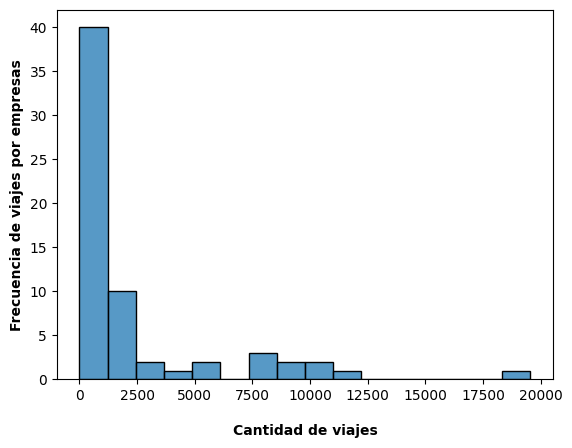

In [ ]:
sns.histplot(ds.viajes_x_compañia.cantidad_de_viajes)
plt.ylabel("Frecuencia de viajes por empresas", fontdict={'weight': 'bold'})
plt.xlabel("Cantidad de viajes", fontdict={'weight': 'bold'}, labelpad=15)

               barrio  promedio_viajes_terminados
0                Loop                10727.466667
1         River North                 9523.666667
2       Streeterville                 6664.666667
3           West Loop                 5163.666667
4              O'Hare                 2546.900000
5           Lake View                 2420.966667
6          Grant Park                 2068.533333
7       Museum Campus                 1510.000000
8          Gold Coast                 1364.233333
9  Sheffield & DePaul                 1259.766667


Text(0.5, 0, 'Barrio')

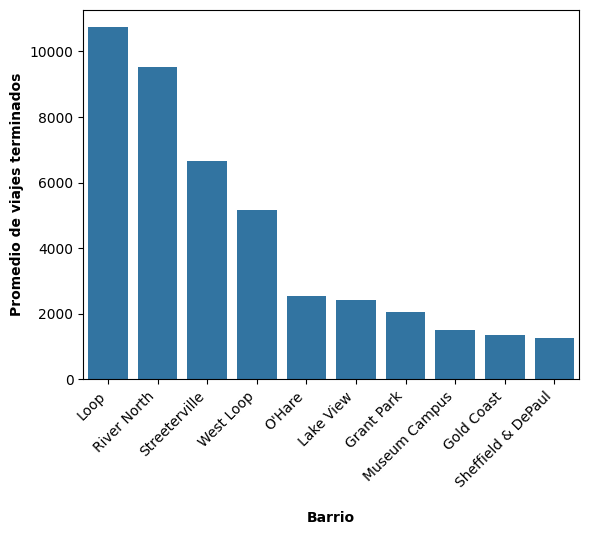

In [ ]:
df = top_10_viajes_x_barrio
g = sns.barplot( x=df.barrio, y=df.promedio_viajes_terminados)
current_locations = g.get_xticks()
g.xaxis.set_major_locator(matplotlib.ticker.FixedLocator(current_locations))
g.set_xticklabels(g.get_xticklabels(), rotation=45, ha='right')
plt.ylabel("Promedio de viajes terminados", fontdict={'weight': 'bold'})
plt.xlabel("Barrio", fontdict={'weight': 'bold'}, labelpad=15)

### 4.6 sacar conclusiones basadas en cada gráfico y explicar los resultados

* Gráfica uno. 10 de las 64 empresas de taxis lideran los viajes arriba  de 6000 a casi los 20,000
* Grafica dos. Voy a intentar correlacionar la cantidad de viajes de empresas con los viajes promedio por barrio


    cantidad_de_viajes  promedio_viajes_terminados
0              19558.0                10727.466667
1              11422.0                 9523.666667
2              10367.0                 6664.666667
3               9888.0                 5163.666667
4               9299.0                 2546.900000
..                 ...                         ...
89               178.5                    3.137931
90               178.5                    3.117647
91               178.5                    2.333333
92               178.5                    1.961538
93               178.5                    1.800000

[94 rows x 2 columns]
El coeficiente de correlación de Pearson (r) entre 'Cantidad De Viajes' y 'Promedio Viajes Terminados' es de 0.9083431811367043, lo que indica una correlación de fuerza: Fuerte o alta.
0.9083431811367043


<Axes: >

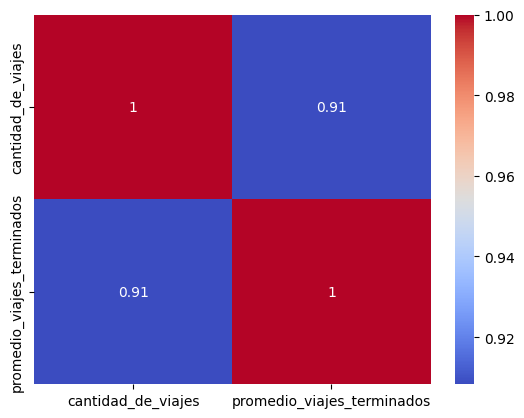

In [ ]:
corr_df = pd.concat([ds.viajes_x_compañia.cantidad_de_viajes, ds.viajes_x_barrio.promedio_viajes_terminados], axis=1)
corr_df.cantidad_de_viajes = corr_df.cantidad_de_viajes.fillna(corr_df.cantidad_de_viajes.median())
print(corr_df)
corr = mph.correlacion_entre(corr_df.cantidad_de_viajes, corr_df.promedio_viajes_terminados)
print(corr)
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm')

Aunque no hay una relación directa entre la cantidad e viajes por compañía y el promedio de viajes terminados por barrio, Haciendo un análisis por correlación, todo indica que cada barrio tiene una predilección por una  empresa específica de taxi

## Paso 5. Prueba de hipótesis

In [ ]:
#revisión y conversión de tipos antes de trabajar con la última consulta
df = ds.loop_ohare
dp.rename_series(df,"start_ts", "recogida")
dp.rename_series(df,"weather_conditions", "clima")
dp.rename_series(df,"duration_seconds", "duracion_segs")
df.clima = df.clima.replace("Good", "Bueno")
df.clima = df.clima.replace("Bad", "Malo")
df.recogida = pd.to_datetime(df.recogida)
df["dia_semana"] = df.recogida.dt.dayofweek

df.info()
print(df.isna().sum())
# Corroboro que todas las recogida tengan fecha en sábado
print(df[df.dia_semana != 5])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   recogida       1068 non-null   datetime64[ns]
 1   clima          1068 non-null   object        
 2   duracion_segs  1068 non-null   float64       
 3   dia_semana     1068 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(1), object(1)
memory usage: 29.3+ KB
recogida         0
clima            0
duracion_segs    0
dia_semana       0
dtype: int64
Empty DataFrame
Columns: [recogida, clima, duracion_segs, dia_semana]
Index: []


Text(0.5, 0, 'Duración de viaje (en segundos)')

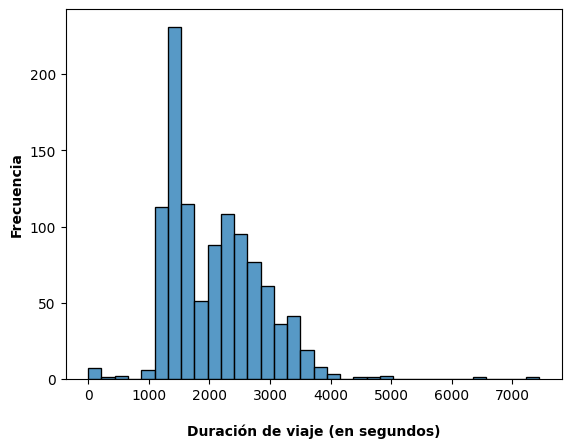

In [ ]:
sns.histplot(df.duracion_segs)
plt.ylabel("Frecuencia", fontdict={'weight': 'bold'})
plt.xlabel("Duración de viaje (en segundos)", fontdict={'weight': 'bold'}, labelpad=15)

In [ ]:
h1 = "La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos"
h0 = "La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare NO cambia los sábados lluviosos"
normal = mph.prueba_de_normalidad(df.duracion_segs)
mph.prueba_estadistica(normal, df[df.clima == "Malo"].duracion_segs, df[df.clima == "Bueno"].duracion_segs, h0, h1)



El tamaño de la muestra es de 1068 (menor a 5000), por lo que se utiliza la prueba de Shapiro-Wilk.
El valor p es de: 7.175491144262307e-22:
  * El valor p es menor al de valor alfa (0.05). Rechazamos la hipótesis nula (H₀). 
  * Los datos NO siguen una distribución normal.

Utilizando prueba no paramétrica Mann-Whitney U:

El valor p es de: 6.716538885593458e-14:
  * El valor p es menor al de valor alfa (0.05). Rechazamos la hipótesis nula (H₀). 
  * La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos


Mi conclusión final es que:

* A traves de correlación de datos que no se encuentran en la misma fuente o que no se relacionan directamente puedo predecir el comportamiento o patrones en el análisis que estoy realizando.
* Puedo relacionar los datos de diversas fuentes para completar el análisis de forma más precisa.